<a href="https://colab.research.google.com/github/ffahrialfikri/Data-Science-2026/blob/main/pertemuan11_fikrialfahri_250401020144.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Fikri Alfahri
Kelas: IF405
NIM: 250401020144

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


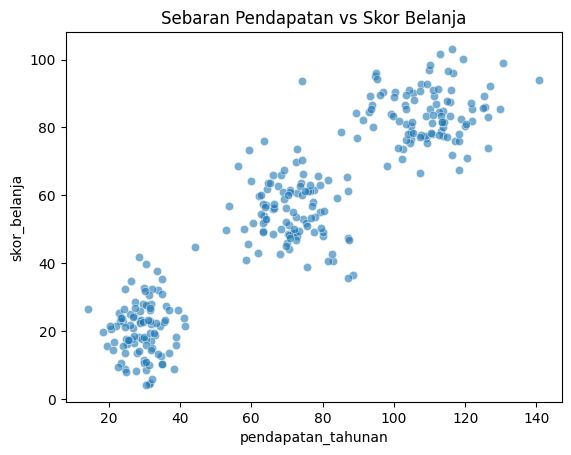

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling: [1. 1.]


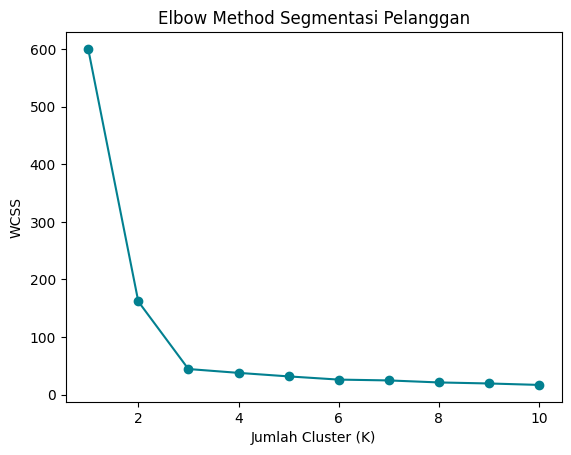

WCSS akhir       : 44.556
Silhouette Score : 0.695

Rata-rata per Cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


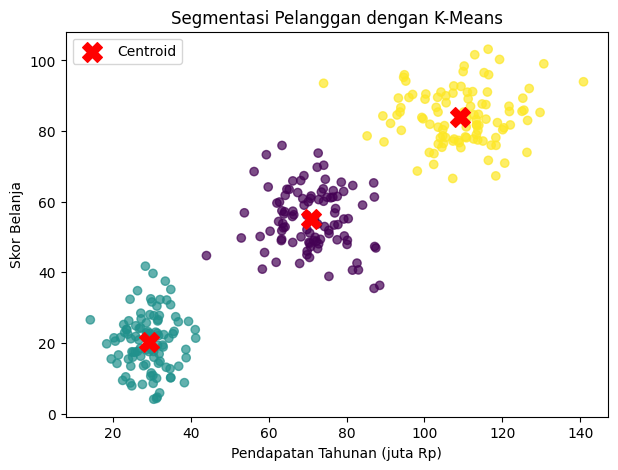

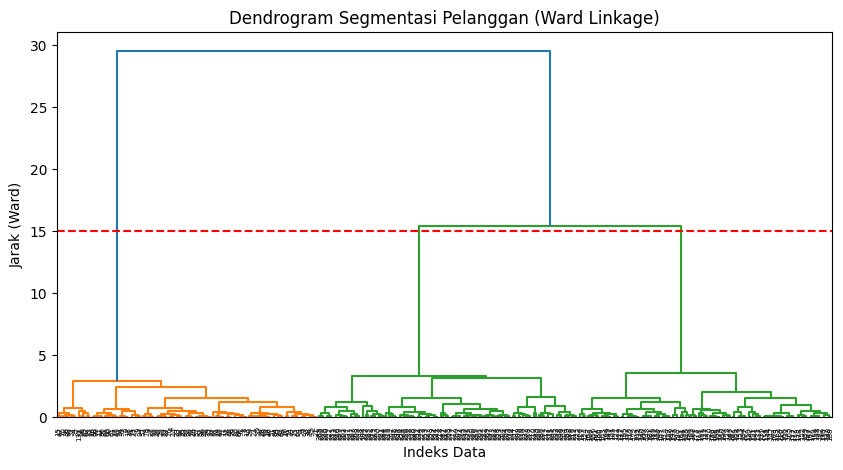

In [1]:
# Langkah 1: Generate & Eksplorasi Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # Hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # Boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()


#Langkah 2: Preprocessing Data
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling:', X_scaled.std(axis=0).round(3))


#Langkah 3: Metode Elbow untuk Menentukan K
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method Segmentasi Pelanggan')
plt.show()


#Langkah 4: Melatih Model K-Means
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir       : {model.inertia_:.3f}')
print(f'Silhouette Score : {silhouette_score(X_scaled, model.labels_):.3f}')
print("\nRata-rata per Cluster:")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

#Langkah 5: Visualisasi Hasil Clustering
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

# Interpretasi Tiap Cluster:
# Cluster 0 = pendapatan rendah, belanja rendah -> Segmen 'Hemat'
# Cluster 1 = pendapatan menengah, belanja menengah -> Segmen 'Menengah'
# Cluster 2 = pendapatan tinggi, belanja tinggi -> Segmen 'Boros/Premium'


#Langkah 6: Hierarchical Clustering (Pembanding)
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # Garis potong
plt.show()

### Kesimpulan Langkah 1: Generate & Eksplorasi Dataset

Pada langkah ini, dataset sintetis berhasil dibuat dengan 300 entri dan 4 fitur (pendapatan_tahunan, skor_belanja, usia, gender), menunjukkan distribusi awal data antara pendapatan dan skor belanja yang terpisah menjadi tiga kelompok yang jelas.

### Kesimpulan Langkah 2: Preprocessing Data

Fitur numerik `pendapatan_tahunan` dan `skor_belanja` telah berhasil di-scaling menggunakan `StandardScaler`. Proses ini penting untuk memastikan semua fitur memiliki skala yang seragam, sehingga algoritma K-Means tidak bias terhadap fitur dengan rentang nilai yang lebih besar.

### Kesimpulan Langkah 3: Metode Elbow untuk Menentukan K

Metode Elbow diterapkan untuk menentukan jumlah cluster (K) yang optimal. Dari plot WCSS, terlihat 'siku' yang jelas pada K=3, menunjukkan bahwa 3 adalah jumlah cluster yang paling sesuai untuk dataset ini.

### Kesimpulan Langkah 4: Melatih Model K-Means

Model K-Means dilatih dengan 3 cluster berdasarkan hasil metode Elbow. Model ini menghasilkan `WCSS` sebesar 44.556 dan `Silhouette Score` 0.695, yang mengindikasikan clustering yang cukup baik. Analisis rata-rata per cluster menunjukkan perbedaan yang jelas antara pendapatan tahunan dan skor belanja untuk setiap segmen, mengidentifikasi segmen 'Hemat', 'Menengah', dan 'Boros/Premium'.

### Kesimpulan Langkah 5: Visualisasi Hasil Clustering

Hasil clustering K-Means divisualisasikan menggunakan scatter plot. Visualisasi ini secara efektif menunjukkan tiga kelompok pelanggan yang berbeda berdasarkan `pendapatan_tahunan` dan `skor_belanja`, dengan centroid cluster yang ditandai dengan jelas. Interpretasi label cluster sebagai 'Hemat', 'Menengah', dan 'Boros/Premium' juga disertakan.

### Kesimpulan Langkah 6: Hierarchical Clustering (Pembanding)

Hierarchical Clustering digunakan sebagai metode pembanding, divisualisasikan melalui dendrogram. Dendrogram ini memberikan perspektif alternatif mengenai struktur pengelompokan data, menguatkan bahwa terdapat tiga cluster utama dalam dataset, konsisten dengan temuan K-Means.

In [ ]:
# Daftar Library yang Digunakan
import numpy
import pandas
import matplotlib.pyplot
import seaborn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
